In [12]:
import pandas as pd
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('/content/Cópia de aprovar_emprestimo.csv', sep=',', index_col=None)

df_dataset = df_dataset.dropna()


# exibe o dataframe
df_dataset.head(3)



,renda_mensal,idade,pontuacao_credito,valor_emprestimo,duracao_emprestimo,outras_dividas,emprestimo_ativo,emprestimo_aprovado
0,7552,68,763,21940,28.0,sim,sim,sim
1,2229,27,367,45199,18.0,não,não,não
2,14403,52,615,48788,24.0,não,sim,sim


In [13]:
df_dataset_X = df_dataset.drop(['outras_dividas','emprestimo_ativo'],axis=1)

In [ ]:
df_dataset_X.dtypes

marca                object
qtd_nucleos           int64
qtd_threads           int64
ram                   int64
gpu_dedicada         object
ram_gpu               int64
entradas_usb          int64
duracao_bateria       int64
resolucao_tela       object
tipo_tela            object
tela_touch           object
armazenamento_hdd     int64
armazenamento_ssd     int64
valor                 int64
dtype: object

In [7]:
!pip install scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 26.1 MB/s eta 0:00:00


In [14]:
s = df_dataset_X.select_dtypes(include='object').columns
df_dataset_X[s] = df_dataset_X[s].astype("category")


In [19]:
from sksurv.preprocessing import OneHotEncoder

Xt = OneHotEncoder().fit_transform(df_dataset_X)
Xt.head()

,renda_mensal,idade,pontuacao_credito,valor_emprestimo,duracao_emprestimo,emprestimo_aprovado=sim
0,7552,68,763,21940,28.0,1.0
1,2229,27,367,45199,18.0,0.0
2,14403,52,615,48788,24.0,1.0
3,2579,40,764,15582,51.0,1.0
4,12618,26,326,35211,42.0,1.0


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Suponha que você tenha seus dados X e os rótulos y
y = df_dataset['emprestimo_aprovado']

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.3, random_state=1)

# Crie um modelo KNN com um certo número de vizinhos (n_neighbors)
knn_model = KNeighborsClassifier(n_neighbors=1)

# Treine o modelo com os dados de treinamento
knn_model.fit(X_train, y_train)

# Faça previsões com o modelo nos dados de teste
y_pred = knn_model.predict(X_test)

# Calcule a acurácia das previsões
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)


Acurácia: 0.7382237487733072


Melhor valor de k: 26
Acurácia no conjunto de teste: 0.8297350343473994


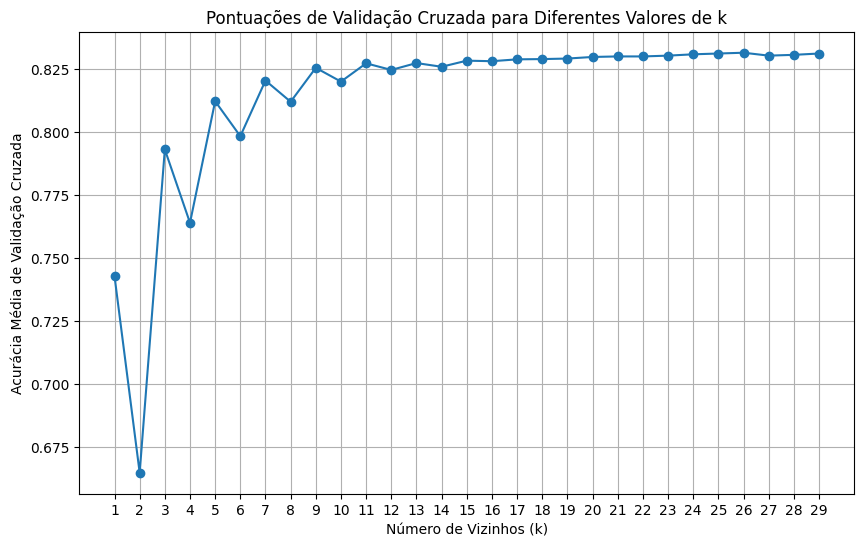

In [17]:
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Suponha que você tenha seus dados X e os rótulos y

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.3, random_state=1234)

# Crie uma lista de valores de k para testar
k_values = list(range(1, 30))

# Inicialize uma lista para armazenar as pontuações de validação cruzada
cross_val_scores = []

# Teste diferentes valores de k usando validação cruzada
for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_train, y_train, cv=5)  # 5-fold cross-validation
    cross_val_scores.append(np.mean(scores))

# Encontre o valor de k com a melhor pontuação média de validação cruzada
best_k = k_values[np.argmax(cross_val_scores)]
print("Melhor valor de k:", best_k)

# Treine o modelo com o melhor valor de k usando todos os dados de treinamento
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

# Avalie o modelo nos dados de teste
accuracy = best_knn_model.score(X_test, y_test)
print("Acurácia no conjunto de teste:", accuracy)


# Plote os resultados da validação cruzada em um gráfico
plt.figure(figsize=(10, 6))
plt.plot(k_values, cross_val_scores, marker='o')
plt.title('Pontuações de Validação Cruzada para Diferentes Valores de k')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia Média de Validação Cruzada')
plt.xticks(k_values)
plt.grid(True)
plt.show()



In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Suponha que você tenha seus dados X e os rótulos y
y = df_dataset['emprestimo_aprovado']

# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(Xt, y, test_size=0.3, random_state=1)

# Criar o modelo de regressão logística
model = LogisticRegression()

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Calcule a acurácia das previsões
accuracy = accuracy_score(y_test, y_pred)
print("Acurácia:", accuracy)

Acurácia: 1.0


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
